## Análisis multivariable, heurística y conclusiones - Análisis exploratorio de datos (EDA)

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-18

### Descripción:

Este notebook cierra el análisis exploratorio del dataset de pacientes con posibles problemas de hígado. Contiene:

1. **Análisis multivariable**: relaciones entre tres o más variables (target + pruebas + género, target + pruebas + grupo de edad, visión de conjunto con pairplot).
2. **Heurística**: una regla sencilla basada en umbrales clínicos, evaluada de forma exploratoria.
3. **Reglas de validación** de datos propuestas a partir de lo observado.
4. **Preparación para Machine Learning**: transformaciones y procesos recomendados (solo como propuesta, sin implementarlos).
5. **Datos adicionales** que mejorarían el proyecto.
6. **Conclusiones generales** del EDA completo.

Como en los notebooks anteriores, aquí no se entrena ningún modelo ni se transforma el dataset de forma permanente.

## 📚 Importar librerías

In [1]:
# librerías base para ciencia de datos
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# configuración para mostrar solo 2 decimales
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

In [3]:
# imprimir versiones de las librerías para reproducibilidad
print("Versión de Python: ", sys.version)
print("Versión de pandas: ", pd.__version__)
print("Versión de seaborn: ", sns.__version__)

Versión de Python:  3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas:  2.3.3
Versión de seaborn:  0.13.2


## 💾 Cargar datos

Cargamos el dataset del proyecto con la misma verificación de los notebooks anteriores. Para los análisis con el target creamos además la columna auxiliar `target_num` (1 = problemas de hígado, 0 = sin problemas) sobre una copia del DataFrame: el archivo original no se modifica.

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = (
    DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"
)

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH, engine="pyarrow")
df["target_num"] = df["Dataset"].astype(str).map({"1": 1, "2": 0})

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

Dataset cargado: 663 filas y 12 columnas


### 📈 Análisis multivariable

#### Target vs pruebas hepáticas vs género

**Pregunta:** la diferencia en las enzimas hepáticas entre pacientes con y sin enfermedad, ¿se mantiene por igual en hombres y mujeres, o hay un patrón distinto por género?

Esta pregunta viene del notebook 03: vimos que el diagnóstico es algo más frecuente en hombres y que ellos tienen pruebas más alteradas. Si la relación prueba–diagnóstico fuera distinta por género, el futuro modelo debería considerar interacciones; si es igual, el género aporta poco por sí solo.

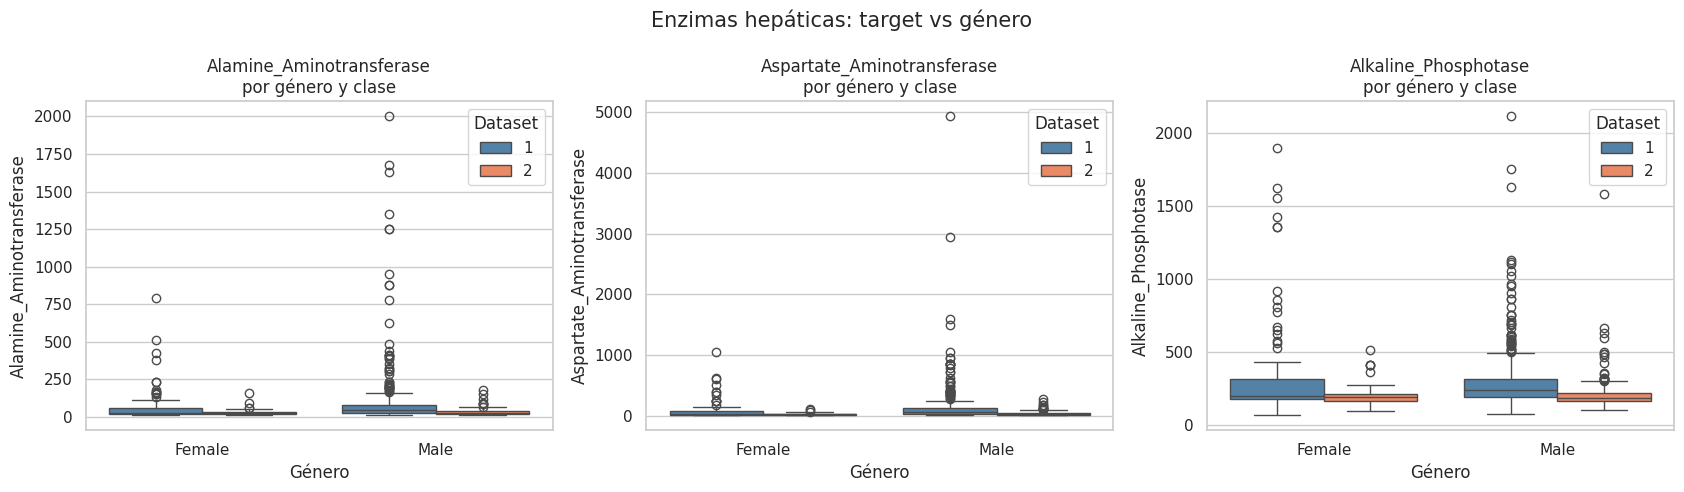

In [5]:
enzimas = [
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Alkaline_Phosphotase",
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col in zip(axes, enzimas):
    sns.boxplot(
        data=df, x="Gender", y=col, hue="Dataset", ax=ax, palette=["steelblue", "coral"]
    )
    ax.set_title(f"{col}\npor género y clase")
    ax.set_xlabel("Género")

plt.suptitle("Enzimas hepáticas: target vs género", fontsize=15)
plt.tight_layout()
plt.show()

**Qué observamos:** dentro de cada género, la caja de la clase "problemas de hígado" (azul) está por encima de la de la clase "sin problemas" (coral) en las tres enzimas. El patrón se repite en hombres y en mujeres con la misma forma.

**Interpretación:** la relación entre las enzimas y el diagnóstico es **consistente entre géneros**: valores altos de enzimas indican enfermedad tanto en hombres como en mujeres. No parece haber una interacción relevante entre género y pruebas.

**Implicación:** de cara al modelo, no sería prioritario construir variables de interacción género×prueba. La señal del género probablemente quede absorbida por las pruebas clínicas.

#### Target vs bilirrubina y albúmina por grupo de edad

**Pregunta:** el patrón "enfermos con más bilirrubina y menos albúmina", ¿se mantiene en todos los grupos de edad o hay tramos donde se rompe?

Para responderla creamos una variable temporal de grupo de edad con `pd.cut` (menores de 30, 30–45, 45–60 y mayores de 60). Esta columna existe solo dentro de este notebook, como paso previo a cada gráfico; el dataset original no se modifica.

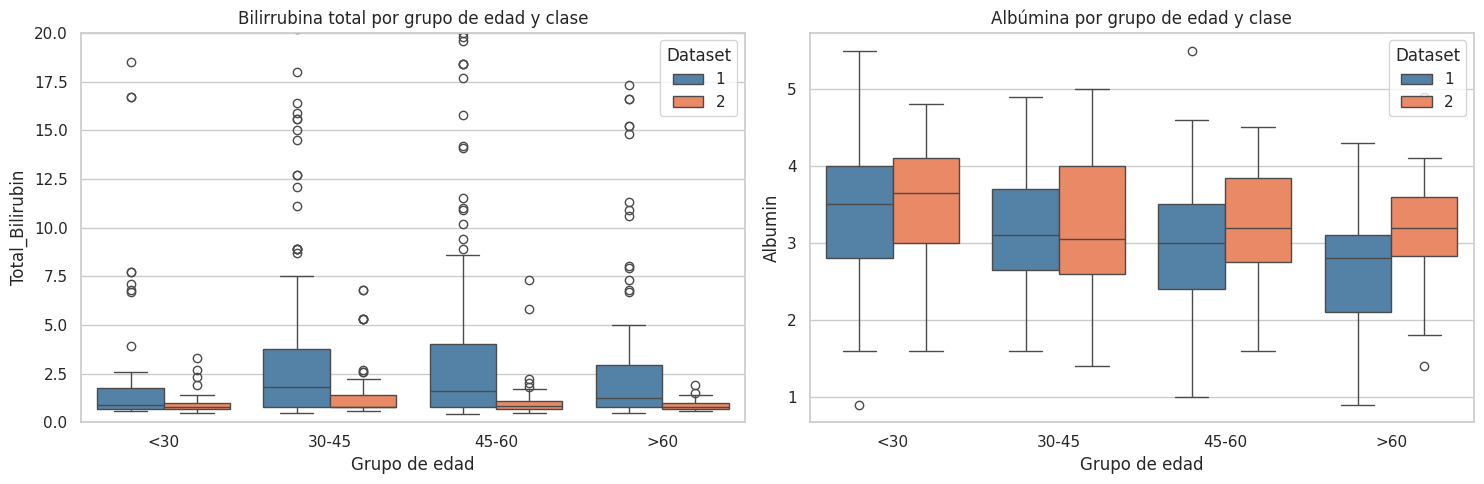

In [6]:
# variable temporal de grupo de edad (solo para este gráfico)
df_temp = df.copy()
df_temp["grupo_edad"] = pd.cut(
    df_temp["Age"].astype("float64"),
    bins=[0, 30, 45, 60, 100],
    labels=["<30", "30-45", "45-60", ">60"],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=df_temp,
    x="grupo_edad",
    y="Total_Bilirubin",
    hue="Dataset",
    ax=axes[0],
    palette=["steelblue", "coral"],
)
axes[0].set_title("Bilirrubina total por grupo de edad y clase")
axes[0].set_xlabel("Grupo de edad")
axes[0].set_ylim(0, 20)  # se recorta el eje para ver las cajas con claridad

sns.boxplot(
    data=df_temp,
    x="grupo_edad",
    y="Albumin",
    hue="Dataset",
    ax=axes[1],
    palette=["steelblue", "coral"],
)
axes[1].set_title("Albúmina por grupo de edad y clase")
axes[1].set_xlabel("Grupo de edad")

plt.tight_layout()
plt.show()

**Qué observamos:** en los cuatro grupos de edad la clase "problemas de hígado" tiene bilirrubina más alta y albúmina más baja que la clase "sin problemas". Las cajas se desplazan de forma paralela en todos los tramos. (En el gráfico de bilirrubina recortamos el eje en 20 para que las cajas fueran legibles; los valores por encima quedan fuera de la vista pero no del análisis.)

**Interpretación:** el patrón clínico es **estable entre grupos de edad**. No se observa ningún tramo de edad donde las pruebas dejen de distinguir las clases.

**Implicación:** las pruebas hepáticas funcionan como señales en toda la población del dataset; no hace falta plantear reglas distintas por edad (al menos para estas dos variables).

#### Target vs género: proporción de enfermedad

**Pregunta:** en números visuales, ¿cómo se reparte el diagnóstico dentro de cada género? Usamos un gráfico de conteo por género separando por clase, para ver el tamaño real de cada grupo además de los porcentajes.

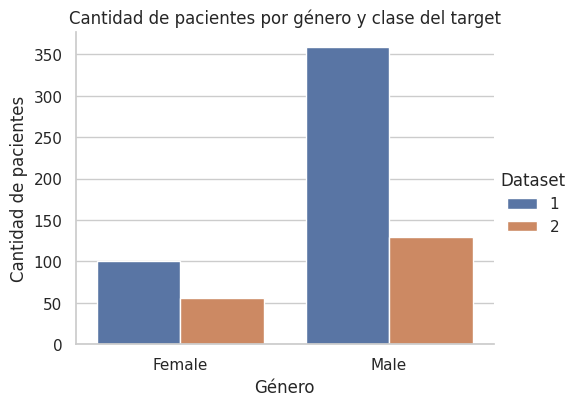

In [7]:
sns.catplot(
    data=df.dropna(subset=["Dataset"]),
    x="Gender",
    hue="Dataset",
    kind="count",
    height=4,
    aspect=1.3,
)
plt.title("Cantidad de pacientes por género y clase del target")
plt.xlabel("Género")
plt.ylabel("Cantidad de pacientes")
plt.show()

**Qué observamos:** en ambos paneles el azul (problemas de hígado) domina, pero más en los hombres (73.6%) que en las mujeres (64.1%), tal como calculamos en el notebook 03.

**Interpretación e implicación:** la diferencia existe pero es modesta y se explica en parte porque los hombres del dataset tienen pruebas más alteradas. Confirmado el patrón en tres análisis distintos, cerramos el estudio del género aquí.

#### Bilirrubina y albúmina conjuntamente según target

**Pregunta:** si combinamos las dos variables con señal más clara pero de signo opuesto (bilirrubina alta = enfermedad; albúmina baja = enfermedad), ¿se separan mejor las clases que con una sola?

Es la pregunta multivariable por excelencia: ¿la combinación de dos variables revela un patrón que cada una por separado no muestra?

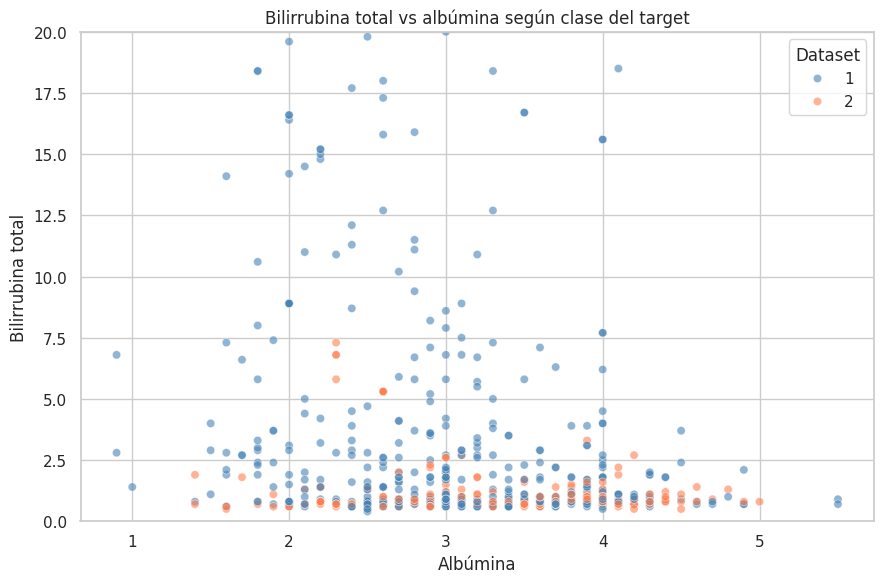

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Albumin",
    y="Total_Bilirubin",
    hue="Dataset",
    palette=["steelblue", "coral"],
    alpha=0.6,
    ax=ax,
)
ax.set_title("Bilirrubina total vs albúmina según clase del target")
ax.set_xlabel("Albúmina")
ax.set_ylabel("Bilirrubina total")
ax.set_ylim(0, 20)  # recorte del eje para legibilidad
plt.tight_layout()
plt.show()

**Qué observamos:** los pacientes sin problemas (coral) se agrupan en la esquina inferior derecha: albúmina alta (la mayoría por encima de 3) y bilirrubina baja (por debajo de ~2.5). Los pacientes con problemas (azul) ocupan un abanico mucho más amplio: desde albúmina alta con bilirrubina moderada hasta albúmina baja con bilirrubina altísima.

**Interpretación:** la combinación de las dos variables sí delimita una "zona sana" razonablemente nítida. Los casos ambiguos son los pacientes enfermos dentro de esa zona (azules mezclados con corales): son los que un modelo basado solo en estas dos variables fallaría.

**Implicación:** este gráfico anticipa que una regla combinada puede funcionar bien para descartar enfermedad (alta especificidad) pero confundirse con los enfermos leves. Es exactamente la intuición que motiva la heurística de la siguiente sección.

#### Todas las variables numéricas frente al target

**Pregunta final del análisis multivariable:** vistas todas juntas, ¿qué pares de variables separan mejor las clases?

Usamos un pairplot con las variables más informativas según el análisis bivariable, coloreando por clase del target. Elegimos seis variables para que el gráfico sea legible; incluir las nueve produciría una matriz difícil de leer sin aportar información nueva.

In [9]:
# lista de las columnas numéricas
numerical_columns = list(
    df.select_dtypes(include=["number", "Int64", "Float64"]).columns
)
numerical_columns

['Age',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Alkaline_Phosphotase',
 'Alamine_Aminotransferase',
 'Aspartate_Aminotransferase',
 'Total_Protiens',
 'Albumin',
 'Albumin_and_Globulin_Ratio',
 'target_num']

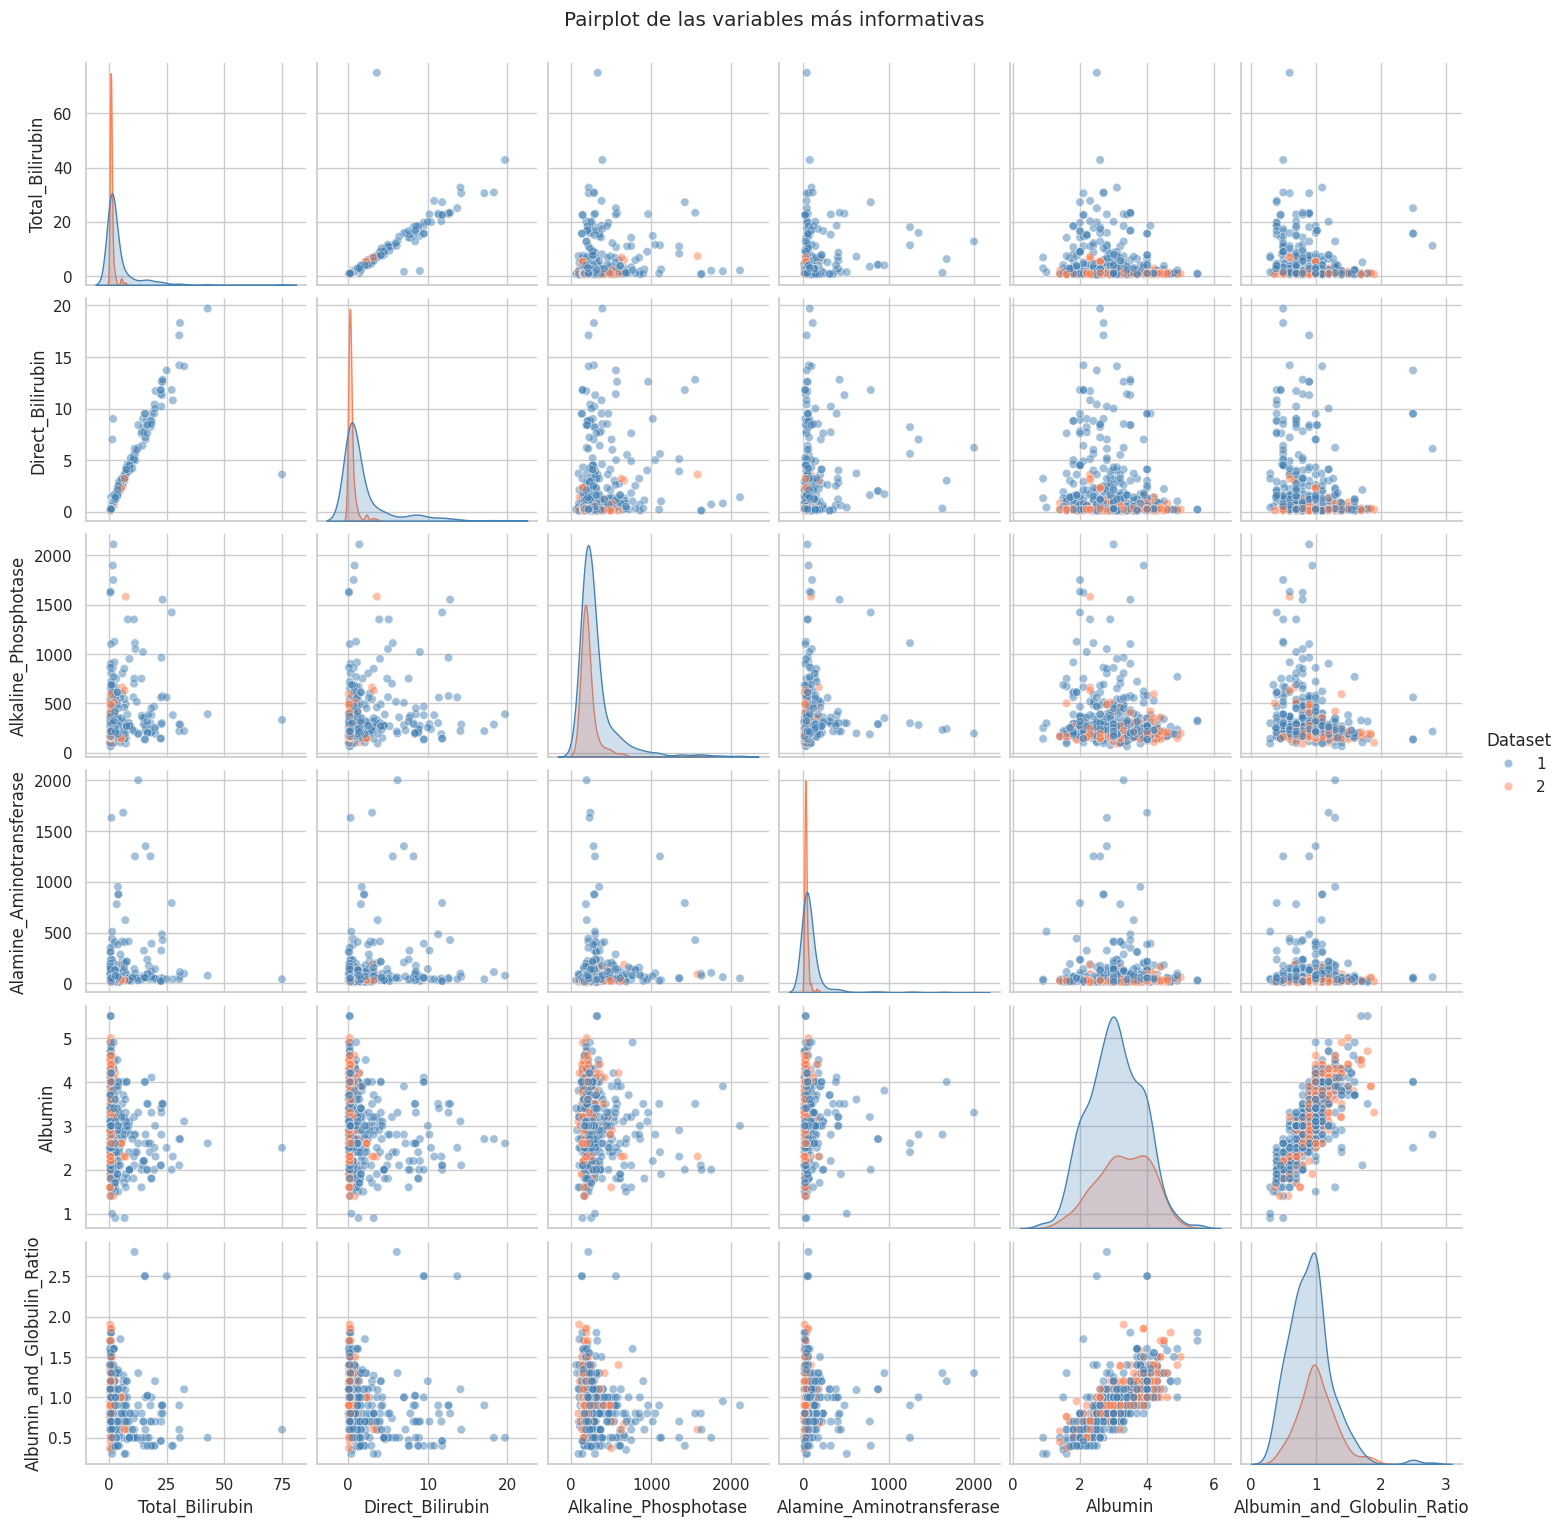

In [10]:
cols_pairplot = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

df_pair = df[cols_pairplot + ["Dataset"]].dropna()

sns.pairplot(
    df_pair,
    hue="Dataset",
    palette=["steelblue", "coral"],
    diag_kind="kde",
    plot_kws={"alpha": 0.5},
)
plt.suptitle("Pairplot de las variables más informativas", y=1.02)
plt.show()

**Qué observamos:** en la diagonal, las densidades de la clase "sin problemas" (coral) son más estrechas y concentradas en valores bajos; las de la clase "problemas" (azul) están más extendidas a la derecha. En los paneles de dispersión, el patrón ya conocido: los sanos forman un bloque compacto y los enfermos se dispersan.

**Interpretación:** ninguna combinación de dos variables separa completamente las clases, pero varias acotan bien la "zona sana". La separación mejora al combinar información de daño (bilirrubinas, enzimas) con información de función (albúmina).

**Implicación:** un clasificador con varias variables debería superar claramente a cualquier regla de una sola variable; también sugiere que modelos capaces de capturar no linealidades (por ejemplo, árboles) pueden tener ventaja sobre modelos puramente lineales, hipótesis que se evaluará en la etapa de modelado.

### 📏 Heurística

**Pregunta del requerimiento:** ¿se puede construir un modelo heurístico viable, es decir, una regla sencilla basada en los patrones encontrados?

**De dónde surge la regla.** Todo el análisis anterior apunta en la misma dirección: los pacientes sanos se concentran en una zona con pruebas en rango normal, y los enfermos se caracterizan por *alguna* prueba alterada — bilirrubina alta, enzimas altas o albúmina baja. Esto sugiere una regla del tipo "si alguna prueba hepática básica está fuera de su rango normal, clasifico al paciente como posible caso de problemas de hígado".

**De dónde salen los umbrales.** Usamos los rangos de referencia estándar de laboratorio clínico para un adulto, que son conocimiento médico general y no valores inventados ni optimizados sobre nuestros datos:

| Prueba | Rango normal aproximado | Umbral de la regla |
|---|---|---|
| Bilirrubina total | 0.1 – 1.2 mg/dL | > 1.2 |
| ALT (Alamine_Aminotransferase) | 7 – 56 U/L | > 56 |
| AST (Aspartate_Aminotransferase) | 10 – 40 U/L | > 40 |
| Albúmina | 3.5 – 5.0 g/dL | < 3.5 |

Estas unidades son las hipótesis que manejamos desde el notebook 02 (la documentación del dataset no las especifica); los rangos citados son los de referencia habitual en laboratorio clínico.

#### Motivación exploratoria de la regla

Antes de definir la regla completa, comprobamos la intuición con datos: entre los pacientes con etiqueta, ¿qué proporción de enfermedad hay entre quienes tienen **todas** las pruebas anteriores en rango normal frente a quienes tienen **alguna** fuera de rango? Usamos una pequeña función auxiliar que calcula el porcentaje de enfermedad de cualquier subconjunto de pacientes, para poder reutilizarla en los dos grupos.

In [11]:
def calcular_porcentaje_enfermedad(df_parcial) -> float:
    # Calcula el porcentaje de pacientes de la clase '1' dentro de df_parcial
    # (subconjunto del DataFrame que debe contener la columna Dataset).
    con_etiqueta = df_parcial.dropna(subset=["Dataset"])
    if len(con_etiqueta) == 0:
        return float("nan")
    return round((con_etiqueta["Dataset"] == "1").mean() * 100, 1)


todas_normales = df[
    (df["Total_Bilirubin"] <= 1.2)
    & (df["Alamine_Aminotransferase"] <= 56)
    & (df["Aspartate_Aminotransferase"] <= 40)
    & (df["Albumin"] >= 3.5)
]

alguna_alterada = df.drop(todas_normales.index)

print("Pacientes con todas las pruebas en rango normal:", len(todas_normales))
print(
    "  % con problemas de hígado:", calcular_porcentaje_enfermedad(todas_normales), "%"
)
print()
print("Pacientes con alguna prueba alterada:", len(alguna_alterada))
print(
    "  % con problemas de hígado:", calcular_porcentaje_enfermedad(alguna_alterada), "%"
)

Pacientes con todas las pruebas en rango normal: 105
  % con problemas de hígado: 53.3 %

Pacientes con alguna prueba alterada: 558
  % con problemas de hígado: 74.4 %


**Resultado:** entre los 105 pacientes con las cuatro pruebas en rango normal, el 53.3% tiene diagnóstico de problemas de hígado; entre los 558 pacientes con alguna prueba alterada, el 74.4%. Es decir, la intuición tiene fundamento (tener alguna alteración eleva la proporción de enfermedad), pero la señal es más débil de lo que uno esperaría.

**Interpretación:** la regla captura una señal real, aunque moderada. Lo más llamativo es que la zona "todas normales" dista de ser segura: más de la mitad de esos pacientes están igualmente diagnosticados con problemas de hígado. Esto es coherente con lo visto en el análisis bivariable: muchos enfermos tienen pruebas cercanas a lo normal, y el diagnóstico proviene de criterios adicionales que no están en el dataset. Este hallazgo anticipa el punto débil de la heurística: fallará sobre todo con enfermos leves.

#### Definición y evaluación exploratoria de la heurística

**Cómo funciona la regla:** un paciente se clasifica como `1` (posibles problemas de hígado) si **al menos una** de las cuatro condiciones se cumple: bilirrubina total > 1.2, ALT > 56, AST > 40 o albúmina < 3.5. Si ninguna se cumple, se clasifica como `2` (sin problemas). Es una regla OR: fácil de explicar y de calcular.

La evaluamos sobre los 627 pacientes con las cuatro pruebas y la etiqueta completas. **Importante:** el resultado es exploratorio y no representa una evaluación de generalización sobre datos no vistos; para eso haría falta separar entrenamiento y prueba, algo que corresponde a la etapa de modelado.

In [12]:
def heuristica_problemas_higado(row) -> str:
    # Heurística basada en umbrales clínicos estándar: clasifica como '1'
    # (posibles problemas de hígado) si alguna prueba hepática básica está
    # fuera de su rango de referencia normal. Devuelve '1' o '2', en el
    # mismo formato de la columna Dataset.
    if (
        row["Total_Bilirubin"] > 1.2
        or row["Alamine_Aminotransferase"] > 56
        or row["Aspartate_Aminotransferase"] > 40
        or row["Albumin"] < 3.5
    ):
        return "1"
    return "2"


df_eval = df.dropna(
    subset=[
        "Total_Bilirubin",
        "Alamine_Aminotransferase",
        "Aspartate_Aminotransferase",
        "Albumin",
        "Dataset",
    ]
).copy()

print(f"Pacientes evaluables: {len(df_eval)} de {len(df)}")

df_eval["prediccion"] = df_eval.apply(heuristica_problemas_higado, axis=1)

Pacientes evaluables: 627 de 663


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de confusión (filas = realidad, columnas = predicción):")
print(confusion_matrix(df_eval["Dataset"], df_eval["prediccion"]))
print()
print(
    classification_report(
        df_eval["Dataset"],
        df_eval["prediccion"],
        target_names=["1 - problemas", "2 - sin problemas"],
    )
)

ModuleNotFoundError: No module named 'sklearn'

: 

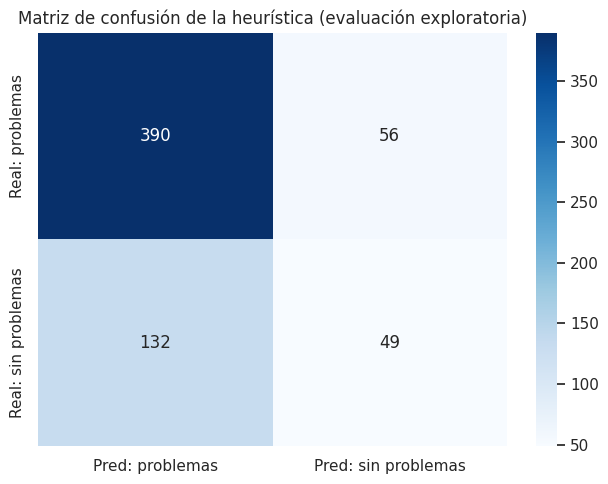

In [ ]:
cm = confusion_matrix(df_eval["Dataset"], df_eval["prediccion"])

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["Pred: problemas", "Pred: sin problemas"],
    yticklabels=["Real: problemas", "Real: sin problemas"],
)
ax.set_title("Matriz de confusión de la heurística (evaluación exploratoria)")
plt.tight_layout()
plt.show()

**Resultado:** la heurística acierta el 70% de los casos. Desglosado por clase:

- Clase `1` (problemas): detecta el **87%** de los enfermos (390 de 446). Solo 56 enfermos se le escapan.
- Clase `2` (sin problemas): solo acierta el **27%** de los sanos (49 de 181). La regla marca como "posible enfermo" a 132 pacientes sanos.

**Interpretación:** la regla es **sensible pero poco específica**: casi no deja pasar enfermos, pero genera muchos falsos positivos. Tiene sentido clínico: los umbrales de laboratorio están pensados para levantar sospecha, no para confirmar diagnóstico, y aquí se cumplen con un simple OR. Además, el desbalance de clases (71/29) favorece que una regla "positivista" acierte mucho en promedio.

**Ventajas de la heurística:**
- Es trivial de explicar y de implementar; no requiere entrenamiento ni infraestructura.
- Su alto recall sobre la clase enferma la hace razonable como filtro de cribado: a quien la regla marque, se le hacen más pruebas.

**Limitaciones:**
- No distingue bien a los sanos (muchos falsos positivos, en parte porque varios pacientes sanos tienen alguna prueba fuera del rango de referencia).
- Usa umbrales generales de población, no optimizados ni validados para este dataset.
- Es una regla fija: no aprende interacciones ni no linealidades (el análisis multivariable sugiere que la combinación de variables aporta más que cada una por separado).
- Se evaluó sobre el mismo dataset con el que se razonó: **este resultado es exploratorio y no representa una evaluación de generalización sobre datos no vistos**.

**Conclusión del bloque:** sí es viable construir una heurística razonable, y sirve como línea base (baseline) contra la que comparar el futuro modelo de Machine Learning. Que una regla tan simple alcance 70% de acierto con 87% de sensibilidad es una señal más de que el dataset contiene información predictiva real; a la vez, su margen de mejora (sobre todo en la clase sana) marca el reto para el modelo.

### Reglas de validación propuestas

A partir de lo observado en el EDA proponemos reglas de validación que un pipeline de datos podría comprobar en el futuro. Cada regla se basa en algo que realmente apareció en el análisis (rangos observados, categorías existentes, nulos y duplicados detectados). Estas reglas quedan como propuesta: no se implementan en esta etapa.

In [ ]:
reglas_validacion = pd.DataFrame(
    {
        "Variable": [
            "Age",
            "Age",
            "Gender",
            "Total_Bilirubin",
            "Direct_Bilirubin",
            "Direct_Bilirubin",
            "Alkaline_Phosphotase",
            "Alamine_Aminotransferase",
            "Aspartate_Aminotransferase",
            "Total_Protiens",
            "Albumin",
            "Albumin_and_Globulin_Ratio",
            "Dataset",
            "Dataset",
        ],
        "Regla": [
            "Valores enteros entre 0 y 120",
            "Solo se permiten hasta 5% de nulos",
            "Solo valores 'Male' o 'Female' (categorías fijas)",
            "Valores > 0 y <= 80 (rango clínicamente posible)",
            "Valores > 0 y <= 25",
            "La bilirrubina directa no puede superar a la total",
            "Valores >= 10 y <= 2500",
            "Valores >= 5 y <= 2500",
            "Valores >= 5 y <= 5000",
            "Valores >= 1 y <= 15",
            "Valores >= 0.5 y <= 6",
            "Valores > 0 y <= 4",
            "Solo valores '1' o '2' (categorías fijas)",
            "Alerta si más del 3% de registros no tiene etiqueta",
        ],
        "Basada en": [
            "Rango observado 4-90; edades fuera de 0-120 serían imposibles",
            "Actualmente hay 1 nulo (0.15%), valor razonable de tolerancia",
            "Solo existen 2 categorías; cualquier otra es un error de carga",
            "Observado 0.4-75; el máximo es extremo pero posible",
            "Observado 0.1-19.7",
            "Restricción fisiológica: la directa es fracción de la total",
            "Observado 63-2110",
            "Observado 10-2000",
            "Observado 10-4929, el valor más extremo del dataset",
            "Observado 2.7-9.6",
            "Observado 0.9-5.5",
            "Observado 0.3-2.8",
            "Solo 2 clases válidas en todo el dataset",
            "Actualmente 15 nulos (2.26%); sin etiqueta no sirven para entrenar",
        ],
    }
)

reglas_validacion

,Variable,Regla,Basada en
0,Age,Valores enteros entre 0 y 120,Rango observado 4-90; edades fuera de 0-120 se...
1,Age,Solo se permiten hasta 5% de nulos,"Actualmente hay 1 nulo (0.15%), valor razonabl..."
2,Gender,Solo valores 'Male' o 'Female' (categorías fijas),Solo existen 2 categorías; cualquier otra es u...
3,Total_Bilirubin,Valores > 0 y <= 80 (rango clínicamente posible),Observado 0.4-75; el máximo es extremo pero po...
4,Direct_Bilirubin,Valores > 0 y <= 25,Observado 0.1-19.7
5,Direct_Bilirubin,La bilirrubina directa no puede superar a la t...,Restricción fisiológica: la directa es fracció...
6,Alkaline_Phosphotase,Valores >= 10 y <= 2500,Observado 63-2110
7,Alamine_Aminotransferase,Valores >= 5 y <= 2500,Observado 10-2000
8,Aspartate_Aminotransferase,Valores >= 5 y <= 5000,"Observado 10-4929, el valor más extremo del da..."
9,Total_Protiens,Valores >= 1 y <= 15,Observado 2.7-9.6


#### Verificación de las reglas contra el dataset actual

Una regla de validación vale más si sabemos cuántas filas la violan hoy. Comprobamos cada regla propuesta contra el dataset completo (los valores nulos no cuentan como violación: tienen su propio control):

In [ ]:
# numero de filas que violan cada regla en el dataset actual
verificacion = pd.DataFrame(
    {
        "Regla": [
            "Age entre 0 y 120",
            "Gender en categorías fijas",
            "Total_Bilirubin > 0 y <= 80",
            "Direct_Bilirubin > 0 y <= 25",
            "Direct_Bilirubin <= Total_Bilirubin",
            "Alkaline_Phosphotase entre 10 y 2500",
            "Alamine_Aminotransferase entre 5 y 2500",
            "Aspartate_Aminotransferase entre 5 y 5000",
            "Total_Protiens entre 1 y 15",
            "Albumin entre 0.5 y 6",
            "Albumin_and_Globulin_Ratio > 0 y <= 4",
            "Dataset en categorías fijas",
        ],
        "Filas que la violan": [
            int(((df["Age"] < 0) | (df["Age"] > 120)).sum()),
            int((df["Gender"].notna() & ~df["Gender"].isin(["Male", "Female"])).sum()),
            int(
                (
                    df["Total_Bilirubin"].notna()
                    & ((df["Total_Bilirubin"] <= 0) | (df["Total_Bilirubin"] > 80))
                ).sum()
            ),
            int(
                (
                    df["Direct_Bilirubin"].notna()
                    & ((df["Direct_Bilirubin"] <= 0) | (df["Direct_Bilirubin"] > 25))
                ).sum()
            ),
            int((df["Direct_Bilirubin"] > df["Total_Bilirubin"]).sum()),
            int(
                (
                    df["Alkaline_Phosphotase"].notna()
                    & (
                        (df["Alkaline_Phosphotase"] < 10)
                        | (df["Alkaline_Phosphotase"] > 2500)
                    )
                ).sum()
            ),
            int(
                (
                    df["Alamine_Aminotransferase"].notna()
                    & (
                        (df["Alamine_Aminotransferase"] < 5)
                        | (df["Alamine_Aminotransferase"] > 2500)
                    )
                ).sum()
            ),
            int(
                (
                    df["Aspartate_Aminotransferase"].notna()
                    & (
                        (df["Aspartate_Aminotransferase"] < 5)
                        | (df["Aspartate_Aminotransferase"] > 5000)
                    )
                ).sum()
            ),
            int(
                (
                    df["Total_Protiens"].notna()
                    & ((df["Total_Protiens"] < 1) | (df["Total_Protiens"] > 15))
                ).sum()
            ),
            int(
                (
                    df["Albumin"].notna()
                    & ((df["Albumin"] < 0.5) | (df["Albumin"] > 6))
                ).sum()
            ),
            int(
                (
                    df["Albumin_and_Globulin_Ratio"].notna()
                    & (
                        (df["Albumin_and_Globulin_Ratio"] <= 0)
                        | (df["Albumin_and_Globulin_Ratio"] > 4)
                    )
                ).sum()
            ),
            int((df["Dataset"].notna() & ~df["Dataset"].isin(["1", "2"])).sum()),
        ],
    }
)

verificacion.set_index("Regla")

,Filas que la violan
Regla,
Age entre 0 y 120,0
Gender en categorías fijas,0
Total_Bilirubin > 0 y <= 80,0
Direct_Bilirubin > 0 y <= 25,0
Direct_Bilirubin <= Total_Bilirubin,3
Alkaline_Phosphotase entre 10 y 2500,0
Alamine_Aminotransferase entre 5 y 2500,0
Aspartate_Aminotransferase entre 5 y 5000,0
Total_Protiens entre 1 y 15,0


**Resultado:** todas las reglas de rango y de categoría se cumplen hoy con cero violaciones, **excepto una**: la restricción fisiológica `Direct_Bilirubin <= Total_Bilirubin`, que **3 filas violan** (los casos ya identificados en el notebook 02: índices 246, 261 y 279, con diferencias flagrantes como total 1.8 / directa 9.0).

**Interpretación:** el dataset actual es limpio en rangos y categorías; el único problema real de consistencia está en la relación entre las dos bilirrubinas. Esto valida las reglas propuestas como controles útiles para futuras cargas de datos: si el dataset crece o se recarga, esta batería detectaría de inmediato registros corruptos.

**Implicación:** la regla de bilirrubinas es la única que exige una decisión inmediata en la etapa de preparación (corregir si hay fuente, o descartar las 3 filas). Las demás quedan como red de seguridad.

**Nota adicional:** también se recomienda una regla global de control de duplicados (alertar cuando más del 10% de las filas estén duplicadas; actualmente 9.0%) y verificar el tipo de dato de cada columna al ingerir los datos (el target debe llegar como categoría con valores `'1'`/`'2'`, no como número).

### Preparación para Machine Learning (propuesta)

Estas son las decisiones de preparación de datos que habrá que evaluar en la etapa de modelado. Quedan explícitamente como **propuesta derivada del EDA**: ninguna se implementa ahora.

In [ ]:
preparacion_ml = pd.DataFrame(
    {
        "Necesidad": [
            "Registros sin etiqueta",
            "Tratamiento de valores nulos",
            "Duplicados",
            "Codificación de Gender",
            "Codificación del target",
            "Transformación de variables asimétricas",
            "Escalamiento",
            "Redundancia / multicolinealidad",
            "Balanceo de clases",
            "Partición de datos",
        ],
        "Detalle": [
            "15 filas (2.26%) no tienen valor en Dataset: descartarlas para el entrenamiento supervisado o explorar usos alternativos",
            "Nulos escasos (<= 2.87% por variable): imputar con la mediana (numéricas) o la moda (Gender); evaluar la pérdida de filas si se prefiere eliminar",
            "60 filas duplicadas (9.0%): evaluar el impacto con y sin duplicados usando validación con datos no vistos",
            "Codificación binaria de Male/Female (por ejemplo, 1/0)",
            "Convertir '1'/'2' a 1/0 respetando su origen de texto",
            "Logarítmica para las cinco pruebas hepáticas (asimetría 3.2-10.6); revisar antes que no haya ceros",
            "Estandarización para modelos sensibles a escala (lineales, k-NN); no necesaria en árboles",
            "Correlaciones altas (bilirrubinas 0.89; ALT-AST 0.78; proteínas-albúmina 0.77): conservar o eliminar una de cada par según el tipo de modelo",
            "Desbalance 71/29: usar ponderación de clases o sobremuestreo de la clase 2, y métricas por clase (F1, recall) y AUC-ROC",
            "Separar entrenamiento y prueba ANTES de imputar o escalar para evitar fuga de información",
        ],
        "Prioridad": [
            "Alta",
            "Alta",
            "Alta",
            "Alta",
            "Alta",
            "Media",
            "Media",
            "Media",
            "Alta",
            "Alta",
        ],
    }
)

preparacion_ml

,Necesidad,Detalle,Prioridad
0,Registros sin etiqueta,15 filas (2.26%) no tienen valor en Dataset: d...,Alta
1,Tratamiento de valores nulos,Nulos escasos (<= 2.87% por variable): imputar...,Alta
2,Duplicados,60 filas duplicadas (9.0%): evaluar el impacto...,Alta
3,Codificación de Gender,Codificación binaria de Male/Female (por ejemp...,Alta
4,Codificación del target,Convertir '1'/'2' a 1/0 respetando su origen d...,Alta
5,Transformación de variables asimétricas,Logarítmica para las cinco pruebas hepáticas (...,Media
6,Escalamiento,Estandarización para modelos sensibles a escal...,Media
7,Redundancia / multicolinealidad,Correlaciones altas (bilirrubinas 0.89; ALT-AS...,Media
8,Balanceo de clases,Desbalance 71/29: usar ponderación de clases o...,Alta
9,Partición de datos,Separar entrenamiento y prueba ANTES de imputa...,Alta


### Transformaciones potenciales

Tabla de transformaciones concretas, con su motivación, beneficio esperado y riesgo. Ninguna se aplica de forma permanente en esta etapa.

In [ ]:
transformaciones = pd.DataFrame(
    {
        "Variable": [
            "Total_Bilirubin",
            "Direct_Bilirubin",
            "Alkaline_Phosphotase",
            "Alamine_Aminotransferase",
            "Aspartate_Aminotransferase",
            "Gender",
            "Dataset",
            "Age (opcional)",
        ],
        "Problema observado": [
            "Asimetría 4.69, cola hasta 75 con mediana 1.0",
            "Asimetría 3.20, cola hasta 19.7 con mediana 0.3",
            "Asimetría 3.90, cola hasta 2110",
            "Asimetría 6.57, cola hasta 2000",
            "Asimetría 10.61 (curtosis 156.9), cola hasta 4929",
            "Variable categórica de texto",
            "Categorías de texto '1'/'2'",
            "Distribución simétrica; la edad podría agruparse en tramos clínicos",
        ],
        "Transformación propuesta": [
            "log(x)",
            "log(x)",
            "log(x)",
            "log(x)",
            "log(x)",
            "Codificación binaria 0/1",
            "Conversión a 1/0 (1 = problemas)",
            "Agrupación opcional en tramos (por ejemplo <30, 30-45, 45-60, >60)",
        ],
        "Beneficio esperado": [
            "Distribución más simétrica; mejores relaciones lineales y menos influencia de extremos",
            "Ídem",
            "Ídem",
            "Ídem",
            "Ídem",
            "Compatibilidad con cualquier modelo",
            "Formato estándar de clasificación binaria",
            "Posible captura de efectos no lineales de la edad",
        ],
        "Riesgo / revisión previa": [
            "Los logaritmos exigen valores > 0 (mínimo observado 0.4: viable)",
            "Mínimo observado 0.1: viable",
            "Mínimo 63: viable",
            "Mínimo 10: viable",
            "Mínimo 10: viable",
            "Sin riesgo relevante",
            "Documentar el mapeo para no invertir las clases",
            "Pérdida de detalle; evaluar con el modelo",
        ],
    }
)

transformaciones

,Variable,Problema observado,Transformación propuesta,Beneficio esperado,Riesgo / revisión previa
0,Total_Bilirubin,"Asimetría 4.69, cola hasta 75 con mediana 1.0",log(x),Distribución más simétrica; mejores relaciones...,Los logaritmos exigen valores > 0 (mínimo obse...
1,Direct_Bilirubin,"Asimetría 3.20, cola hasta 19.7 con mediana 0.3",log(x),Ídem,Mínimo observado 0.1: viable
2,Alkaline_Phosphotase,"Asimetría 3.90, cola hasta 2110",log(x),Ídem,Mínimo 63: viable
3,Alamine_Aminotransferase,"Asimetría 6.57, cola hasta 2000",log(x),Ídem,Mínimo 10: viable
4,Aspartate_Aminotransferase,"Asimetría 10.61 (curtosis 156.9), cola hasta 4929",log(x),Ídem,Mínimo 10: viable
5,Gender,Variable categórica de texto,Codificación binaria 0/1,Compatibilidad con cualquier modelo,Sin riesgo relevante
6,Dataset,Categorías de texto '1'/'2',Conversión a 1/0 (1 = problemas),Formato estándar de clasificación binaria,Documentar el mapeo para no invertir las clases
7,Age (opcional),Distribución simétrica; la edad podría agrupar...,Agrupación opcional en tramos (por ejemplo <30...,Posible captura de efectos no lineales de la edad,Pérdida de detalle; evaluar con el modelo


### Datos adicionales útiles

Información que, de estar disponible, podría mejorar la comprensión y la capacidad predictiva del proyecto. No inventamos fuentes: solo señalamos qué sería útil y qué dificultades tendría obtenerlo.

In [ ]:
datos_adicionales = pd.DataFrame(
    {
        "Dato adicional": [
            "Identificador anónimo de paciente",
            "Antecedentes de consumo de alcohol",
            "Serología de hepatitis B y C",
            "Índice de masa corporal (IMC)",
            "Ultrasonido / pruebas de imagen hepáticas",
            "Gamma-glutamil transferasa (GGT)",
            "Tiempo de protrombina (INR)",
            "Motivo de la consulta / contexto clínico",
        ],
        "Por qué ayudaría": [
            "Distinguiría pacientes repetidos de coincidencias entre pacientes distintos, resolviendo la duda de los duplicados",
            "El alcohol es una de las principales causas de enfermedad hepática; separaría etiologías",
            "La hepatitis viral es causa frecuente de hepatopatía crónica; identificaría subgrupos",
            "El hígado graso asociado a obesidad es una causa creciente de alteración de pruebas",
            "Detecta esteatosis, cirrosis y masas que las analíticas no revelan",
            "Enzima sensible de vía biliar, complementaría ALP en el diagnóstico colestásico",
            "Mide la función de coagulación hepática, otro indicador de función como la albúmina",
            "Explicaría por qué se pidieron las pruebas y en qué contexto se etiquetó el diagnóstico",
        ],
        "Dificultad para obtenerlo": [
            "Requiere recontactar la fuente original de los datos",
            "Requiere historia clínica o encuesta al paciente",
            "Requiere pruebas serológicas específicas",
            "Requiere medidas antropométricas",
            "Requiere acceso a estudios de imagen y su informe",
            "Prueba de laboratorio adicional",
            "Prueba de laboratorio adicional",
            "Requiere acceso a la historia clínica completa",
        ],
    }
)

datos_adicionales

,Dato adicional,Por qué ayudaría,Dificultad para obtenerlo
0,Identificador anónimo de paciente,Distinguiría pacientes repetidos de coincidenc...,Requiere recontactar la fuente original de los...
1,Antecedentes de consumo de alcohol,El alcohol es una de las principales causas de...,Requiere historia clínica o encuesta al paciente
2,Serología de hepatitis B y C,La hepatitis viral es causa frecuente de hepat...,Requiere pruebas serológicas específicas
3,Índice de masa corporal (IMC),El hígado graso asociado a obesidad es una cau...,Requiere medidas antropométricas
4,Ultrasonido / pruebas de imagen hepáticas,"Detecta esteatosis, cirrosis y masas que las a...",Requiere acceso a estudios de imagen y su informe
5,Gamma-glutamil transferasa (GGT),"Enzima sensible de vía biliar, complementaría ...",Prueba de laboratorio adicional
6,Tiempo de protrombina (INR),"Mide la función de coagulación hepática, otro ...",Prueba de laboratorio adicional
7,Motivo de la consulta / contexto clínico,Explicaría por qué se pidieron las pruebas y e...,Requiere acceso a la historia clínica completa


## 📊 Conclusiones generales del EDA

Respondemos a las preguntas que guían el requerimiento, con los resultados obtenidos en los cuatro notebooks.

**¿Cómo son nuestros datos?** 663 registros de pacientes con 11 variables: edad, género, ocho pruebas de función hepática y el diagnóstico. Es una tabla clínica compacta (~55 KB), sin variables de texto, fechas ni booleanas, y sin identificadores de paciente. El dataset es pequeño: cualquier modelo futuro tendrá ejemplos limitados, sobre todo de la clase minoritaria y del género femenino.

**¿Qué problemas de calidad tienen?** Nulos escasos pero generalizados (98 celdas, 1.34%, en las 11 columnas; el target tiene 15), 60 filas duplicadas (9.0%, 51 grupos) que no se pueden explicar sin identificador de paciente, valores extremos muy marcados en las pruebas hepáticas (AST hasta 4929, ALT hasta 2000, ALP hasta 2110, bilirrubina hasta 75) que son clínicamente posibles y no deben eliminarse por defecto, y **3 filas con bilirrubina directa mayor que la total** (índices 246, 261 y 279), una inconsistencia fisiológica que casi con seguridad corresponde a errores de captura y que es el único problema de consistencia real detectado (todas las demás reglas de validación propuestas se cumplen hoy sin violaciones).

**¿Qué variables son potencialmente importantes y cómo se relacionan con el target?** Por correlación lineal y por diferencia de medianas entre clases: las bilirrubinas (Directa 0.25, Total 0.22), la fosfatasa alcalina (0.18), las transaminasas (ALT 0.165, AST 0.156) y la albúmina (-0.14) y el ratio A/G (-0.14), más débilmente la edad (0.13). El género tiene una señal menor (73.6% de enfermedad en hombres vs 64.1% en mujeres) que parece explicarse por las diferencias en las pruebas. Las proteínas totales no distinguen las clases. La excepción es `Total_Protiens`, estadísticamente indistinguible entre clases (Mann-Whitney p = 0.65); las demás diferencias son significativas (p < 0.005). Ninguna variable separa las clases por sí sola; los pacientes sanos forman un grupo compacto de pruebas normales y los enfermos se dispersan hacia valores alterados.

**¿Existe desbalance?** Sí, moderado: 71% de la clase con problemas de hígado frente a 29% de la clase sin problemas (460 vs 188 pacientes con etiqueta). Condicionará las métricas y las técnicas de entrenamiento del futuro modelo.

**¿Qué relaciones interesantes existen?** Redundancias clínicamente esperables: Total_Bilirubin–Direct_Bilirubin (0.89), ALT–AST (0.78), Total_Protiens–Albumin (0.77), Albumin–ratio A/G (0.69). La relación pruebas–diagnóstico es consistente entre géneros y entre grupos de edad.

**¿Es viable una heurística?** Sí: una regla OR con umbrales clínicos estándar (bilirrubina > 1.2, ALT > 56, AST > 40 o albúmina < 3.5) clasifica correctamente el 70% de los pacientes evaluables, detecta el 87% de los enfermos pero solo el 27% de los sanos. Es útil como línea base y como lógica de cribado. Dos matices: su evaluación fue exploratoria, sobre el dataset completo (no sobre datos no vistos), y solo cubre los 627 pacientes con las cuatro pruebas y la etiqueta completas (los 105 con alguna prueba faltante quedan fuera de su alcance).

**¿Qué reglas de validación proponemos?** Rangos clínicamente posibles por variable, categorías fijas para Gender y Dataset, la restricción fisiológica de que la bilirrubina directa no supere a la total, control de porcentaje de nulos (con alerta específica para el target) y control de duplicados. Detalle completo en la sección correspondiente. Al verificarlas contra el dataset actual, la única violada es la de bilirrubinas (3 filas); el resto se cumplen sin excepciones.

**¿Qué preparación necesitará la etapa de modelado?** Descartar o tratar los 15 registros sin etiqueta, imputar nulos (mediana/moda), decidir sobre duplicados, codificar Gender y el target, transformar logarítmicamente las pruebas hepáticas, escalar según el modelo, resolver la redundancia entre variables correlacionadas, balancear clases y separar entrenamiento/prueba antes de imputar o escalar para evitar fuga de información.

**¿Qué información adicional sería útil?** Un identificador anónimo de paciente (aclararía los duplicados), antecedentes de alcohol, serología de hepatitis viral, IMC, pruebas de imagen, GGT y tiempo de protrombina. Todas requieren acceso a historia clínica o pruebas adicionales.

**¿Qué debería hacerse en la siguiente etapa?** Con la información de este EDA, la etapa de preparación de datos está bien delimitada: aplicar y documentar las decisiones propuestas, construir los conjuntos de entrenamiento y prueba, y entrenar una primera familia de modelos usando la heurística (70% de acierto, 87% de sensibilidad) como línea base mínima a superar, con métricas por clase y AUC-ROC dadas las clases desbalanceadas.

## 📋 Resumen para las próximas fases

Esta sección condensa lo esencial del EDA para quien continúe el proyecto, o para retomarlo más adelante sin tener que releer los cuatro notebooks completos. No sustituye la lectura detallada, pero debería bastar para recordar qué encontramos y qué toca hacer.

### Hallazgos principales

- El dataset reúne 663 pacientes con 11 variables: la edad, el género, ocho pruebas de función hepática y el diagnóstico (`Dataset`).
- Los pacientes sin problemas de hígado forman un grupo compacto, con pruebas en valores bajos; los enfermos se dispersan hacia valores alterados. Ninguna variable separa las clases por sí sola.
- Todas las variables clínicas menos `Total_Protiens` difieren de forma significativa entre clases (Mann-Whitney con p < 0.005); las proteínas totales no distinguen (p = 0.65).
- El patrón entre las pruebas y el diagnóstico es consistente entre géneros y entre grupos de edad: no hacen falta reglas distintas por población.

### Calidad de los datos

- 98 celdas con valores nulos (1.34% del total). Las 15 filas sin etiqueta en el target no servirán para entrenar un modelo supervisado.
- 60 filas duplicadas (9.0%), en 51 grupos. Sin un identificador de paciente no se puede saber si son repeticiones del mismo individuo o coincidencias entre pacientes distintos.
- 3 filas con bilirrubina directa mayor que la total (índices 246, 261 y 279): una imposibilidad fisiológica que casi con seguridad son errores de captura.
- Valores extremos muy marcados en las pruebas hepáticas (AST hasta 4929, ALT hasta 2000, ALP hasta 2110, bilirrubina hasta 75), pero clínicamente posibles: no deben eliminarse por defecto.

### Variables relevantes

- Con correlación positiva con la enfermedad: las bilirrubinas (directa 0.246, total 0.219), la fosfatasa alcalina (0.179) y las transaminasas (ALT 0.165, AST 0.156).
- Con correlación negativa (valores bajos asociados a enfermedad): la albúmina (-0.141) y el ratio albúmina/globulina (-0.139).
- La edad aporta una señal pequeña pero significativa (p = 0.0016): los enfermos son mayores en promedio (medianas de 46 frente a 39 años).

### Variables que requieren atención

- `Total_Bilirubin` y `Direct_Bilirubin`: redundantes entre sí (r = 0.89) y afectadas por las 3 filas inconsistentes.
- Otras redundancias a resolver según el modelo: ALT–AST (r = 0.78), Total_Protiens–Albumin (r = 0.77), Albumin–ratio A/G (r = 0.69).
- Las cinco pruebas hepáticas tienen asimetrías fuertes (entre 3.2 y 10.6): candidatas naturales a transformación logarítmica.
- `Total_Protiens`: sin señal por sí sola; decidir si se conserva en la etapa de modelado.
- `Gender`: 8 nulos y una muestra con 76% de hombres; conviene revisar las métricas por separado para cada género.

### Target

`Dataset` es una variable categórica de texto con valores `'1'` (problemas de hígado: 460 pacientes, 71%) y `'2'` (sin problemas: 188, 29%), más 15 registros sin etiqueta. El desbalance es moderado y tiene consecuencias directas: un clasificador que siempre predijera "problemas" acertaría el 71% de las veces, así que el accuracy por sí solo será una métrica engañosa. Toca usar métricas por clase y AUC-ROC, y evaluar técnicas de balanceo.

### Preparación futura (antes de entrenar un modelo)

1. Resolver las 3 filas con bilirrubinas inconsistentes (corregir si se consigue la fuente original o descartarlas).
2. Decidir qué hacer con los 15 registros sin etiqueta (lo habitual será excluirlos del entrenamiento).
3. Decidir sobre los duplicados: evaluar el modelo con y sin ellos, usando validación con datos no vistos.
4. Separar entrenamiento y prueba **antes** de imputar nulos o escalar, para evitar fuga de información.
5. Imputar los nulos restantes (mediana para numéricas, moda para el género).
6. Codificar `Gender` y el target; aplicar transformación logarítmica a las pruebas hepáticas si el modelo lo aprovecha; escalar según el tipo de modelo.

### Heurística como línea base

La regla OR con umbrales clínicos (bilirrubina total > 1.2, ALT > 56, AST > 40 o albúmina < 3.5) acierta el 70% de los casos evaluables, detecta el 87% de los enfermos pero solo el 27% de los sanos. Es una evaluación exploratoria sobre el dataset completo, no una medida de generalización. Sirve como referencia mínima: cualquier modelo entrenado debería superar estos números, sobre todo el recall de la clase de pacientes sanos, que es donde la regla falla.

### Próximos pasos

1. Aplicar y documentar la preparación de datos según los puntos anteriores.
2. Construir los conjuntos de entrenamiento y prueba.
3. Entrenar una primera familia de modelos y compararlos explícitamente contra la heurística.
4. Informar siempre métricas por clase, AUC-ROC y resultados separados por género.

## 📖 Referencias

- Pruebas de función hepática (referencia clínica general): <https://www.ncbi.nlm.nih.gov/books/NBK482489/>
- Análisis bivariable y multivariable: <https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/>
- Métricas de clasificación con clases desbalanceadas: <https://scikit-learn.org/stable/modules/model_evaluation.html>